In [4]:
import pandas as pd
import time
import matplotlib.pyplot as plt
import os
import statsmodels.api as smf
import numpy as np
import seaborn as sns
import sys
sys.path.append("..")  # db_config.py lives in the repo root
from db_config import read_sql

df= []


df = read_sql("""SELECT Issuer_title, COUNT(*) AS Loans, tier
        FROM (
        SELECT CONCAT(t.issuer_id, ' - ', t3.issuer_name) AS Issuer_title
        ,CASE WHEN TRY_CAST(t.credit_score AS FLOAT) IS NULL THEN 'NaN'
        WHEN TRY_CAST(t.credit_score AS FLOAT) < 680 THEN '<680'
        WHEN TRY_CAST(t.credit_score AS FLOAT) < 740 THEN '680-739'
        ELSE '740+' END
        + ' / ' +
        CASE WHEN TRY_CAST(t.ltv AS FLOAT) IS NULL THEN 'NaN'
        WHEN TRY_CAST(t.ltv AS FLOAT) <= 90 THEN '<=90'
        ELSE '>90' END AS tier
        FROM gnma_static_table t
        LEFT JOIN issuer_info t3 ON t3.issuer_number = t.issuer_id
        WHERE t3.issuer_group = 'Mega' AND TRY_CAST(t.credit_score AS FLOAT) IS NOT NULL AND TRY_CAST(t.ltv AS FLOAT) IS NOT NULL
        ) x
        GROUP BY Issuer_title, tier""")

print(df.head())

                          issuer_title   loans            tier
0  3871 - FREEDOM MORTGAGE CORPORATION  126504     <680 / <=90
1  3871 - FREEDOM MORTGAGE CORPORATION  445869      <680 / >90
2  3871 - FREEDOM MORTGAGE CORPORATION   86705  680-739 / <=90
3  3871 - FREEDOM MORTGAGE CORPORATION  344338   680-739 / >90
4  3871 - FREEDOM MORTGAGE CORPORATION  103868     740+ / <=90


In [5]:
betas = pd.read_csv(r"c:\Users\H59045\OneDrive - US Department of Housing and Urban Development\Python Scripts\tier_betas_dlq90.csv", index_col="tier")

merged = df.merge(betas, left_on="tier", right_index=True, how="left")

print(merged.head(15))

                           issuer_title   loans            tier  beta_tier
0   3871 - FREEDOM MORTGAGE CORPORATION  126504     <680 / <=90   0.741607
1   3871 - FREEDOM MORTGAGE CORPORATION  445869      <680 / >90   1.154773
2   3871 - FREEDOM MORTGAGE CORPORATION   86705  680-739 / <=90   0.357361
3   3871 - FREEDOM MORTGAGE CORPORATION  344338   680-739 / >90   0.794934
4   3871 - FREEDOM MORTGAGE CORPORATION  103868     740+ / <=90   0.134519
5   3871 - FREEDOM MORTGAGE CORPORATION  246227      740+ / >90   0.423589
6           4042 - ROCKET MORTGAGE, LLC  271739     <680 / <=90   0.741607
7           4042 - ROCKET MORTGAGE, LLC  424031      <680 / >90   1.154773
8           4042 - ROCKET MORTGAGE, LLC  140216  680-739 / <=90   0.357361
9           4042 - ROCKET MORTGAGE, LLC  229888   680-739 / >90   0.794934
10          4042 - ROCKET MORTGAGE, LLC  124766     740+ / <=90   0.134519
11          4042 - ROCKET MORTGAGE, LLC  152243      740+ / >90   0.423589
12   4094 - PENNYMAC LOAN

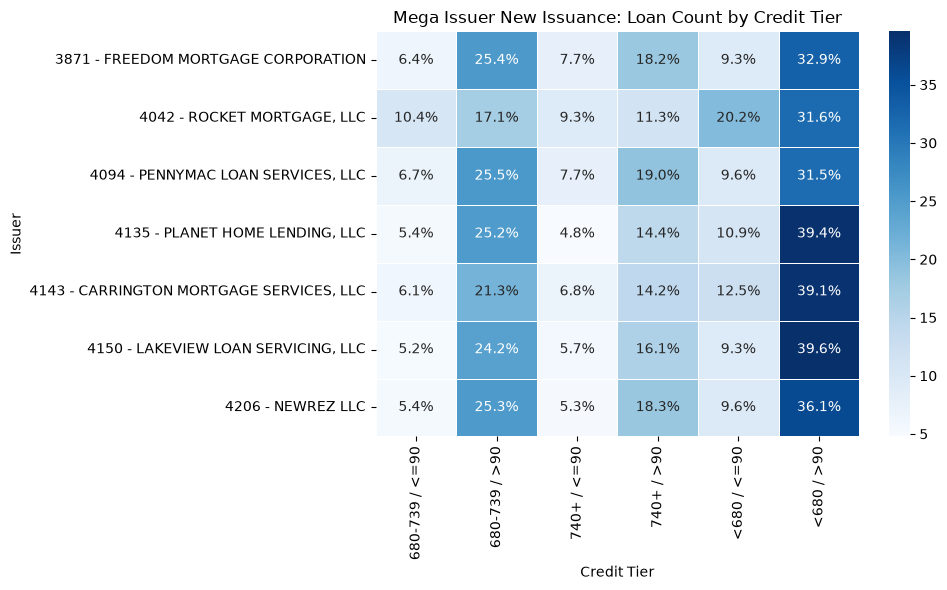

In [ ]:
counts = pd.crosstab(merged["issuer_title"], merged["tier"], values=merged["loans"], aggfunc='sum').fillna(0)

pct = counts.div(counts.sum(axis=1), axis=0)*100

plt.figure(figsize=(10, 6))
sns.heatmap(pct,
            annot=pct.round(1).astype(str) + "%",  fmt='',     # show counts with commas
            cmap='Blues',          # replace with your existing cmap
            linewidths=0.5)
plt.title('Mega Issuer Current Book: Loan Count by Credit Tier')
plt.xlabel('Credit Tier')
plt.ylabel('Issuer')
plt.tight_layout()
plt.show()
